<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do Treino: {len(y_train)}")
print(f"Tamanho do Teste: {len(y_test)}")

print("\nProporção das classes no Teste:")
print(pd.Series(y_test).value_counts(normalize=True))

Tamanho do Treino: 120
Tamanho do Teste: 30

Proporção das classes no Teste:
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(random_state=42)

clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Acurácia no Treino: {acc_train:.2%}")
print(f"Acurácia no Teste: {acc_test:.2%}")

Acurácia no Treino: 100.00%
Acurácia no Teste: 93.33%


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

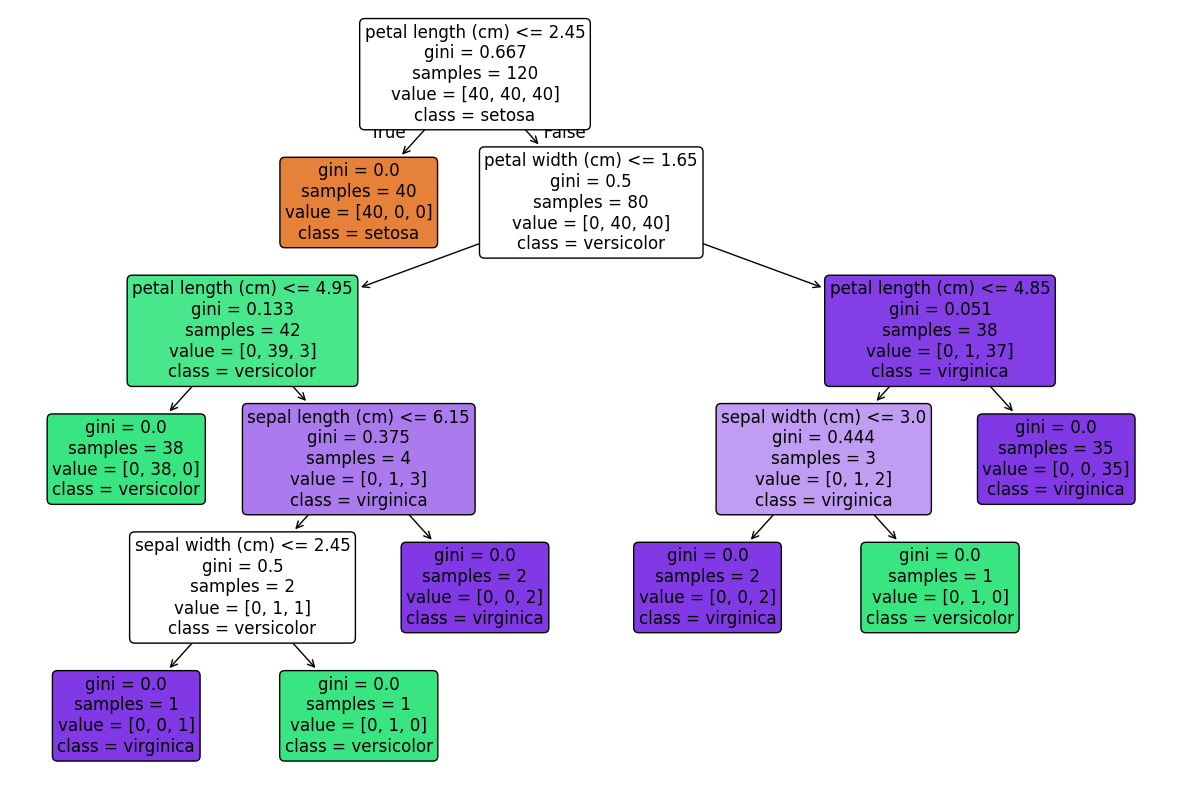

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))

plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True)

plt.show()

1. O atributo que aparece na sua raiz é o petal length (cm) ou petal width (cm).

2. A profundidade da árvore é 5

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]
resultados = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    resultados.append({
        'Max Depth (Param)': d if d is not None else "None",
        'Acurácia Treino': f"{accuracy_score(y_train, y_train_pred):.2%}",
        'Acurácia Teste': f"{accuracy_score(y_test, y_test_pred):.2%}",
        'Profundidade Real': clf.get_depth(),
        'Nº de Folhas': clf.get_n_leaves()
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

Max Depth (Param) Acurácia Treino Acurácia Teste  Profundidade Real  Nº de Folhas
                1          66.67%         66.67%                  1             2
                2          96.67%         93.33%                  2             3
                3          98.33%         96.67%                  3             5
                4          99.17%         93.33%                  4             7
                5         100.00%         93.33%                  5             8
                6         100.00%         93.33%                  5             8
                7         100.00%         93.33%                  5             8
                8         100.00%         93.33%                  5             8
                9         100.00%         93.33%                  5             8
             None         100.00%         93.33%                  5             8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

O overfitting começa na profundidade 4, e fica mais forte na profundidade 5.

Quando não é dado um limite de profundidade máxima, a árvore tem liberdade total de continuar a se extender até ela classificar todas as amostras ou não ter mais dados para dividir.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [17]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

clf_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)

clf_gini.fit(X_train, y_train)
clf_entropy.fit(X_train, y_train)

dados_comparativos = []

for nome, modelo in [("Gini", clf_gini), ("Entropy", clf_entropy)]:
    dados_comparativos.append({
        "Critério": nome,
        "Profundidade": modelo.get_depth(),
        "Nº de Folhas": modelo.get_n_leaves(),
        "Acurácia Treino": f"{accuracy_score(y_train, modelo.predict(X_train)):.2%}",
        "Acurácia Teste": f"{accuracy_score(y_test, modelo.predict(X_test)):.2%}"
    })

df_comp = pd.DataFrame(dados_comparativos)
print(df_comp.to_string(index=False))

Critério  Profundidade  Nº de Folhas Acurácia Treino Acurácia Teste
    Gini             5             8         100.00%         93.33%
 Entropy             5             8         100.00%         93.33%


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [18]:

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

resultados_leaf = []

for m in range(1, 11):
    clf = DecisionTreeClassifier(min_samples_leaf=m, random_state=42)
    clf.fit(X_train, y_train)

    acc_train = accuracy_score(y_train, clf.predict(X_train))
    acc_test = accuracy_score(y_test, clf.predict(X_test))

    resultados_leaf.append({
        "min_samples_leaf": m,
        "Acurácia Treino": acc_train,
        "Acurácia Teste": acc_test,
        "Profundidade": clf.get_depth()
    })

df_leaf = pd.DataFrame(resultados_leaf)
print(df_leaf.to_string(index=False))

 min_samples_leaf  Acurácia Treino  Acurácia Teste  Profundidade
                1         1.000000        0.933333             5
                2         0.983333        0.933333             4
                3         0.983333        0.966667             3
                4         0.983333        0.966667             3
                5         0.966667        0.933333             3
                6         0.966667        0.933333             3
                7         0.966667        0.933333             3
                8         0.966667        0.933333             3
                9         0.966667        0.933333             3
               10         0.966667        0.933333             3


Melhor Modelo:
DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

Acurácia:
Treino: 96.67%
Teste: 93.33%

Parâmetros:
min_samples_leaf=5
criterion='gini'
max_depth=None (pois o min_samples_leaf já faz o controle sozinho)